# ECT Sensor – Exploratory Data Analysis

## Purpose
Explores the COMSOL-simulated EM sensor dataset.  
Inverse Problem: Given a multi frequency eddy current signal, predict relative permeability (μr) and resistivity (ρ) for the material.

## Raw Structure
- 9 resistivity values and 25 permeability values = 225 unique combinations
- across 8 frequencies (375 Hz- 48 kHz)
- raw format = 9x25x8 = 1800 rows, one per μr/ρ/frequency combination 
- The two receiver coils (coil 2, coil 3) return complex mutual-inductance values; their difference gives the differential (gradiometer) signal used for inversion.

## EDA Goals
1. Analyse the differential signal and its response to each target across 8 frequencies
2. Quantify how each feature's variation splits between two targets and their interaction
3. PCA for multivariate analysis

In [1]:
import sys
from pathlib import Path

# Add project root to path 
# current path =d:\Study\Uni\ect-inversion\notebooks\full_spectrum
project_root = Path.cwd().parents[1]

# adds project root to sys.path to enable absolute imports from 
# 'ect-inversion' directory
sys.path.insert(0, str(project_root))

# Figures folder path
fig_dir = project_root/"figures"/"full_spectrum"
fig_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedFormatter

## 1. Load raw


In [2]:
from src.data import load_raw,rename_columns, compute_differential

raw = load_raw('train.xlsx')
print('Shape:',raw.shape)
raw.head()

Shape: (1800, 7)


,MP,res (ohm m),freq (Hz),real L_coil2 (H),imag L_coil2 (H),real L_coil3 (H),imag L_coil3 (H)
0,1.0,2.000000e-07,375,0.000557,3.882330e-08,0.000660,-0.000099
1,1.0,2.000000e-07,750,0.000558,1.576814e-05,0.000602,-0.000165
2,1.0,2.000000e-07,1500,0.000579,2.712947e-05,0.000480,-0.000208
3,1.0,2.000000e-07,3000,0.000606,1.212852e-05,0.000360,-0.000171
4,1.0,2.000000e-07,6000,0.000609,-2.368435e-05,0.000304,-0.000121


## 2. Rename Columns

COMSOL exports verbose expression strings as column headers. Rename to short, readable names used throughout the rest of the notebook.

In [3]:
raw = rename_columns(raw)
print(raw.columns.tolist())

print(f'\nUnique Permeabilities ({len(raw["permeability"].unique())}): {sorted(raw["permeability"].unique())}')
print(f'Unique Resistivities ({len(raw["resistivity"].unique())}): {sorted(raw["resistivity"].unique())}')
print(f'Unique Frequencies ({len(raw["frequency"].unique())}): {sorted(raw["frequency"].unique())}')

['permeability', 'resistivity', 'frequency', 'coil2_real', 'coil2_imag', 'coil3_real', 'coil3_imag']

Unique Permeabilities (25): [np.float64(1.0), np.float64(1.334), np.float64(1.778), np.float64(2.371), np.float64(3.162), np.float64(4.217), np.float64(5.623), np.float64(7.499), np.float64(10.0), np.float64(13.335), np.float64(17.783), np.float64(23.714), np.float64(31.623), np.float64(42.17), np.float64(56.234), np.float64(74.989), np.float64(100.0), np.float64(133.352), np.float64(177.828), np.float64(237.137), np.float64(316.228), np.float64(421.697), np.float64(562.341), np.float64(749.894), np.float64(1000.0)]
Unique Resistivities (9): [np.float64(2e-07), np.float64(3e-07), np.float64(4e-07), np.float64(5e-07), np.float64(6e-07), np.float64(7e-07), np.float64(8e-07), np.float64(9e-07), np.float64(1e-06)]
Unique Frequencies (8): [np.int64(375), np.int64(750), np.int64(1500), np.int64(3000), np.int64(6000), np.int64(12000), np.int64(24000), np.int64(48000)]


## 3. Differential (Gradiometer) Inductance

The sensor uses a gradiometer configuration: coil 2 (Dummy) and coil 3 (Sensing) are wound in opposition so that the common-mode background signal cancels.
Subtracting coil 2 from coil 3 gives the net differential mutual inductance **H**, whose real and imaginary parts carry the material response.  
The sign of H depends on coil orientation in the COMSOL model.
$$H = \text{coil}_3 - \text{coil}_2$$
### Physical Meaning of H
- H_Real = represents the in-phase component. captures how strongly the material magnetises in response to the sensor's field.
- H_Imag = represents the out-of-phase component. captures energy loss due to eddy current flowing inside the material.

In [4]:
raw = compute_differential(raw)

raw[['frequency', 'H_real', 'H_imag']].head(10)

,frequency,H_real,H_imag
0,375,0.000103,-0.000099
1,750,0.000044,-0.000181
2,1500,-0.000099,-0.000235
3,3000,-0.000246,-0.000184
4,6000,-0.000305,-0.000097
5,12000,-0.000314,-0.000046
6,24000,-0.000316,-0.000028
7,48000,-0.000327,-0.000016
8,375,0.000097,-0.000098
9,750,0.000039,-0.000179


In [5]:
''' Wide dataframe format 
(225 x 18, where each row is a unique combination of μr x ρ 
with their corresponding real and imaginary inductance values across 8 frequencies)
'''
from src.data import reshape_wide

wide_df = reshape_wide(raw)
print('Wide DF Shape: ', wide_df.shape)
wide_df.head()

Wide DF Shape:  (225, 18)


,permeability,resistivity,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
0,1.0,2.000000e-07,-0.000099,-0.000181,-0.000235,-0.000184,-0.000097,-0.000046,-0.000028,-0.000016,0.000103,0.000044,-0.000099,-0.000246,-0.000305,-0.000314,-0.000316,-0.000327
1,1.0,3.000000e-07,-0.000098,-0.000179,-0.000232,-0.000182,-0.000097,-0.000047,-0.000028,-0.000015,0.000097,0.000039,-0.000101,-0.000247,-0.000306,-0.000315,-0.000317,-0.000328
2,1.0,4.000000e-07,-0.000099,-0.000178,-0.000230,-0.000180,-0.000096,-0.000046,-0.000028,-0.000015,0.000093,0.000035,-0.000104,-0.000247,-0.000306,-0.000315,-0.000318,-0.000329
3,1.0,5.000000e-07,-0.000100,-0.000178,-0.000228,-0.000178,-0.000095,-0.000046,-0.000028,-0.000015,0.000091,0.000031,-0.000106,-0.000248,-0.000306,-0.000315,-0.000318,-0.000329
4,1.0,6.000000e-07,-0.000102,-0.000178,-0.000227,-0.000177,-0.000095,-0.000046,-0.000028,-0.000015,0.000089,0.000028,-0.000109,-0.000249,-0.000306,-0.000315,-0.000318,-0.000329


In [6]:
# Design audit — this is a deterministic full-factorial sweep, not a sample.
# The useful checks are structural, not statistical.
n_mu  = raw['permeability'].nunique()
n_rho = raw['resistivity'].nunique()
n_f   = raw['frequency'].nunique()

assert len(raw) == n_mu * n_rho * n_f, 'grid is incomplete'
assert not raw.duplicated(['permeability', 'resistivity', 'frequency']).any(), 'duplicate grid keys'
assert raw.groupby(['permeability', 'resistivity']).size().nunique() == 1, 'grid is unbalanced'
assert raw.notna().all().all(), 'missing values present'

print(f'Full factorial: {n_mu} μr × {n_rho} ρ × {n_f} freq = {n_mu * n_rho * n_f} rows')
print('Complete, balanced, no duplicate keys, no missing values.')
print('\nNo outlier or missingness checks follow — COMSOL output is deterministic,')
print('so every row is exactly what the forward model produces.')

Full factorial: 25 μr × 9 ρ × 8 freq = 1800 rows
Complete, balanced, no duplicate keys, no missing values.

No outlier or missingness checks follow — COMSOL output is deterministic,
so every row is exactly what the forward model produces.


## 4. Target Grid Distributions

The two targets are swept on **different kinds of grid**, and plotting them on one axis hides
that completely — their units differ by nine orders of magnitude. So one column each.

Each column shows the same values twice: on a **linear** axis (top) and a **log10** axis
(bottom). The dashed curves are the exact densities a log-uniform grid (∝ 1/μr) and a linear
grid (∝ ρ) would produce, drawn so the shape claim is visible rather than asserted.

**Binning.** One bin per design level, with edges at the midpoints between consecutive levels
(arithmetic in linear space, geometric in log space). Equal-width bins over only 25 or 9
discrete levels alias into spurious empty bins; midpoint edges cannot.

**What the counts are and are not.** This is a deterministic full-factorial sweep, not a
sample. Every μr level appears in exactly 9 rows and every ρ level in exactly 25 rows *by
construction*, so the bar heights describe the **design**, not a population. What is
informative is the *shape*: where the sweep chose to place resolution.

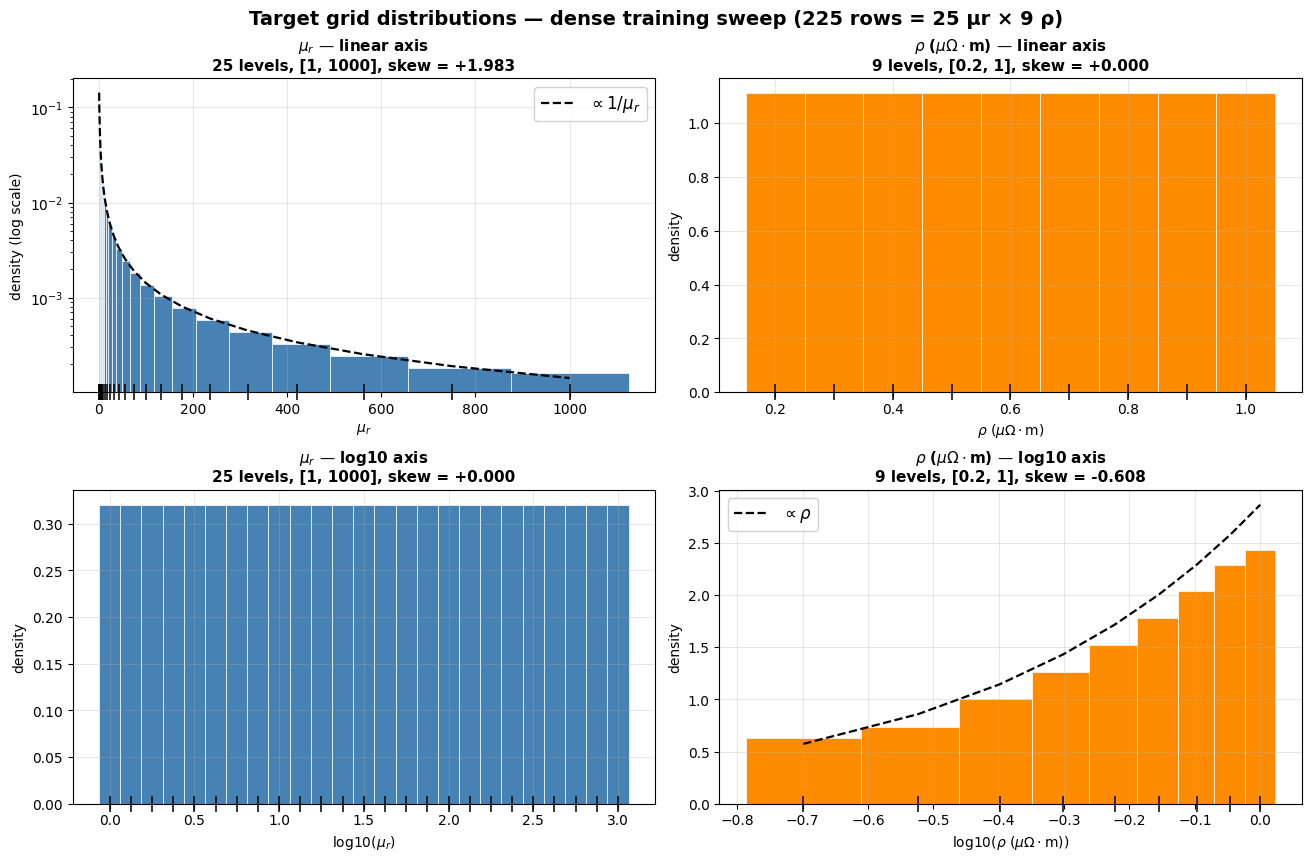

permeability  25 levels  [1, 1000]
              mean 159.8  median 31.62  skew +1.983  skew(log10) +0.000
              spacing:  1 distinct level-to-level ratio(s), 24 distinct difference(s)
resistivity    9 levels  [2e-07, 1e-06]
              mean 6e-07  median 6e-07  skew +0.000  skew(log10) -0.608
              spacing:  8 distinct level-to-level ratio(s),  1 distinct difference(s)

One distinct ratio => log-uniform.  One distinct difference => linear.


In [7]:
from scipy.stats import skew

# One bin per design level, edges at the midpoints between levels (arithmetic in
# linear space, geometric in log space). Equal-width bins would alias a 25- or
# 9-level grid into spurious empty bins; midpoint edges cannot.
def midpoint_edges(v):
    mid = (v[:-1] + v[1:]) / 2
    return np.r_[2 * v[0] - mid[0], mid, 2 * v[-1] - mid[-1]]

# rho is displayed in micro-ohm-metres purely so neither axis needs a 1e-6 offset
# label. mu_r is dimensionless.
PANELS = {
    'permeability': dict(scale=1.0, unit=r'$\mu_r$',                    colour='steelblue'),
    'resistivity':  dict(scale=1e6, unit=r'$\rho$ ($\mu\Omega\cdot$m)', colour='darkorange'),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)
fig.suptitle('Target grid distributions \u2014 dense training sweep '
             '(225 rows = 25 \u03bcr \u00d7 9 \u03c1)', fontsize=14, fontweight='bold')

for col, (tgt, cfg) in enumerate(PANELS.items()):
    vals   = wide_df[tgt].values * cfg['scale']
    levels = np.sort(np.unique(vals))

    for row, log in enumerate([False, True]):
        ax    = axes[row, col]
        x     = np.log10(vals)   if log else vals
        xl    = np.log10(levels) if log else levels

        ax.hist(x, bins=midpoint_edges(xl), density=True, color=cfg['colour'],
                edgecolor='white', linewidth=0.5)

        # Rug of the actual level positions. The x-axis transform pins the marks to
        # the bottom of the axes whatever the y-scale is.
        ax.plot(xl, np.zeros_like(xl), '|', color='black', markersize=11,
                markeredgewidth=1.1, clip_on=False,
                transform=ax.get_xaxis_transform())

        # A log-uniform grid has density proportional to 1/x on a linear axis; a
        # linear grid has density proportional to x on a log10 axis.
        if tgt == 'permeability' and not log:
            ref, ref_lab, ref_loc = 1 / xl, r'$\propto 1/\mu_r$', 'upper right'
        elif tgt == 'resistivity' and log:
            ref, ref_lab, ref_loc = 10 ** xl, r'$\propto \rho$', 'upper left'
        else:
            ref = None
        if ref is not None:
            ref = ref / np.trapezoid(ref, xl)          # unit area, matching density=True
            ax.plot(xl, ref, 'k--', linewidth=1.6, label=ref_lab)
            ax.legend(fontsize=12, loc=ref_loc, framealpha=0.9)

        # The 1/x density spans three decades; on a linear y-axis every bar past the
        # first would be invisible. Only this panel needs the log y-axis.
        crushed = (tgt == 'permeability' and not log)
        if crushed:
            ax.set_yscale('log')
        else:
            ax.set_ylim(bottom=0)
            ax.margins(y=0.15)

        # Stats live in the subtitle rather than a floating box - nothing to overlap.
        ax.set_title(f'{cfg["unit"]} \u2014 {"log10" if log else "linear"} axis\n'
                     f'{len(levels)} levels, [{levels[0]:.4g}, {levels[-1]:.4g}], '
                     f'skew = {skew(x):+.3f}', fontweight='bold', fontsize=11)
        ax.set_xlabel(f'log10({cfg["unit"]})' if log else cfg['unit'])
        ax.set_ylabel('density (log scale)' if crushed else 'density')
        ax.grid(True, alpha=0.3)

plt.savefig(fig_dir / 'target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# The numbers behind the panels, in the targets' own units.
for tgt in PANELS:
    v  = wide_df[tgt].values
    lv = np.sort(wide_df[tgt].unique())
    print(f'{tgt:13s} {len(lv):2d} levels  [{lv[0]:.4g}, {lv[-1]:.4g}]\n'
          f'{"":13s} mean {v.mean():.4g}  median {np.median(v):.4g}  '
          f'skew {skew(v):+.3f}  skew(log10) {skew(np.log10(v)):+.3f}\n'
          f'{"":13s} spacing: {len(np.unique(np.round(lv[1:] / lv[:-1], 2))):2d} distinct '
          f'level-to-level ratio(s), '
          f'{len(np.unique(np.round(np.diff(lv), 12))):2d} distinct difference(s)')
print('\nOne distinct ratio => log-uniform.  One distinct difference => linear.')

**Key Observations from the Plot:**

- **μr is log-uniform.** 25 levels from 1 to 1000 with a single level-to-level ratio of
  10^(1/8) ≈ 1.3335 — 24 *different* absolute steps, from 0.33 to 250. On a linear axis the
  density follows 1/μr exactly (skew **+1.98**, mean 159.8 vs median 31.6); on a log10 axis it is
  flat (skew **0.000**). Seventeen of the 25 levels sit below μr = 50.
- **ρ is linear-uniform.** 9 levels from 2e-7 to 1e-6 with a single step of 1e-7 — 8 *different*
  ratios, from 1.11 to 1.50. Flat on a linear axis (skew **0.000**), mildly left-skewed on a
  log10 axis (skew **−0.608**).
- **The sweep spends its resolution on μr and spends it logarithmically.** ρ gets 9 evenly
  spaced levels inside a single factor of 5; μr gets 25 levels across three decades.

**Consequences for modelling:**

- Errors should be scored **relative**, not absolute — a fixed absolute error means something
  completely different at μr = 1 than at μr = 1000. This is why the models wrap the target in
  `TransformedTargetRegressor(func=np.log)` and are reported as MAPE.
- Holding out a **single** μr level for validation is unsafe: because the grid is geometric, the
  two flanking levels average (in log space) to exactly the held-out value, so a nearest-neighbour
  model can reconstruct it without learning anything. Bands of ≥2 levels break that. On the linear
  ρ grid the artifact cannot arise, which is why the held-out band widths are asymmetric
  (`BAND_WIDTH = {'permeability': 2, 'resistivity': 1}` in the modelling notebook).

## 5. Visualise Inductance vs Frequency

Four subplots in a 2×2 grid:
- **Top row** — fix resistivity, vary permeability across all  μr values.  
- **Bottom row** — fix permeability, vary resistivity across all  ρ values.  
- **Left column** — real part of H (the in-phase component, reflecting magnetic flux linkage).  
- **Right column** — imaginary part of H (the out of phase component, reflecting eddy-current loss).  

**Skin depth physics:**
The key physical principle governing all four subplots is skin depth, the depth to which
the sensor's field penetrates the material:
$$\delta = \sqrt{\frac{\rho}{\pi f \mu}}$$

- Higher frequency -> shallower skin depth -> signal only sees the surface
- Higher μr -> shallower skin depth 
- Higher ρ -> deeper skin depth 

**Note:** Each panel holds one target at a mid-range value. This is a representative slice, not a general one.

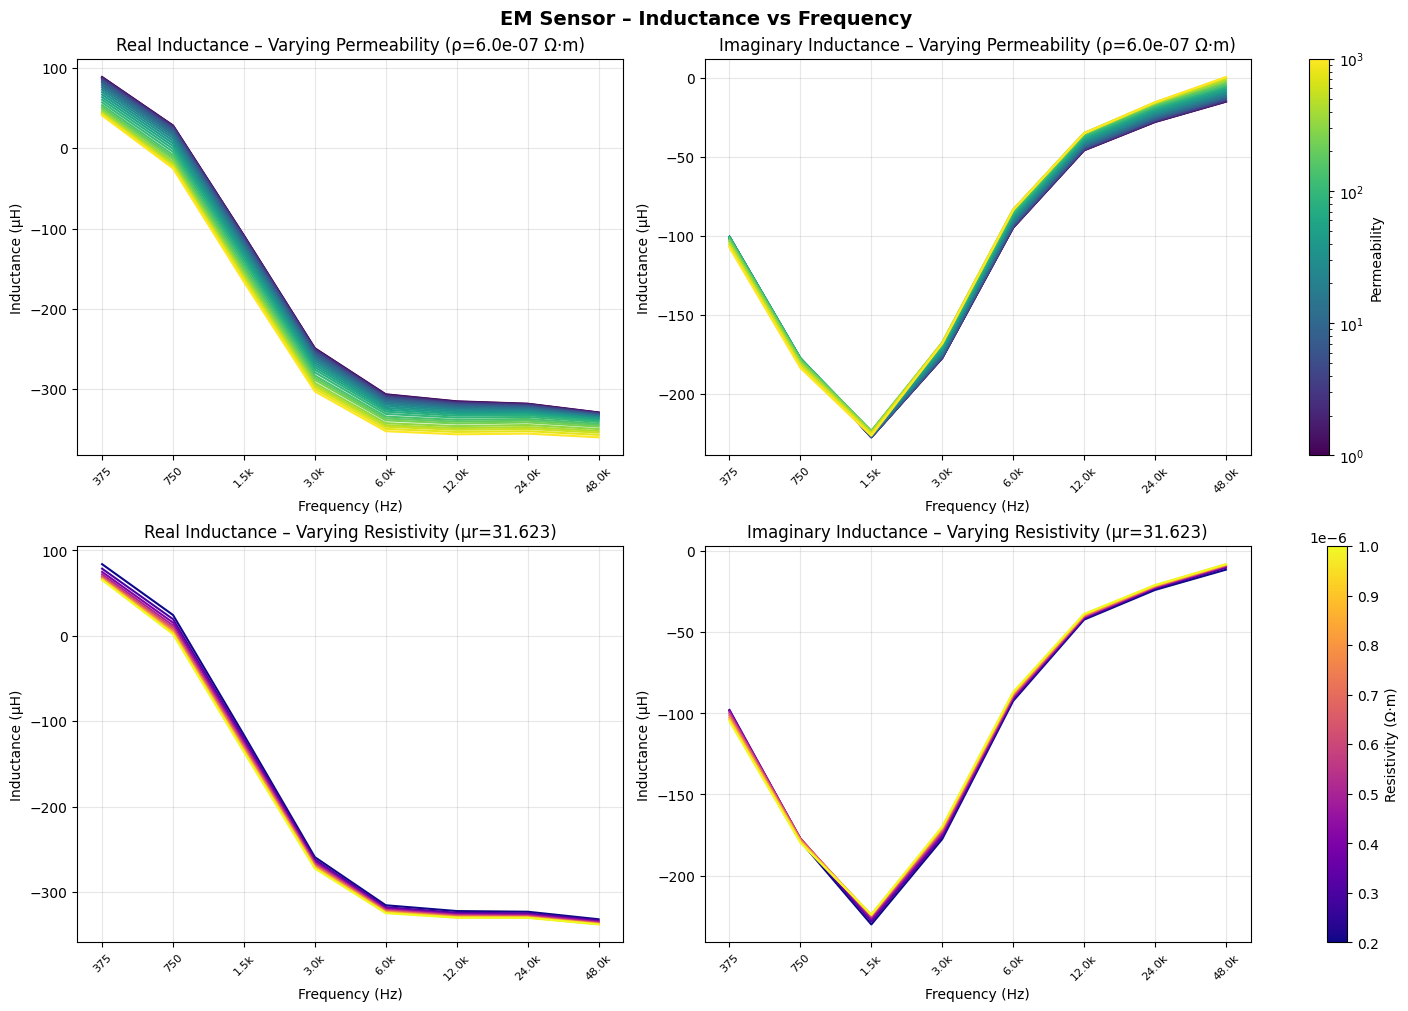

In [8]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm

# Sorted unique parameter values across the simulation sweep
permeabilities = sorted(raw['permeability'].unique())
resistivities  = sorted(raw['resistivity'].unique())

# Choose fixed values for the "vary-one" subplots (middle value in each sweep)
res_fixed  = resistivities[len(resistivities) // 2]
perm_fixed = permeabilities[len(permeabilities) // 2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle('EM Sensor – Inductance vs Frequency', fontsize=14, fontweight='bold')

# --- Top row: vary permeability, fix resistivity ---
# Isolate rows with the fixed resistivity, then loop over all μr values.
subset1 = raw[raw['resistivity'] == res_fixed]
colors1  = plt.get_cmap('viridis')(np.linspace(0, 1, len(permeabilities)))

for i, perm in enumerate(permeabilities):
    g = subset1[subset1['permeability'] == perm].sort_values('frequency')
    # Scale H from H to μH for readability
    axes[0, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors1[i], label=f'μr={perm:g}')
    axes[0, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors1[i], label=f'μr={perm:g}')

axes[0, 0].set_title(f'Real Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')
axes[0, 1].set_title(f'Imaginary Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')

# --- Bottom row: vary resistivity, fix permeability ---
subset2 = raw[raw['permeability'] == perm_fixed]
colors2  = plt.get_cmap('plasma')(np.linspace(0, 1, len(resistivities)))

for i, res in enumerate(resistivities):
    g = subset2[subset2['resistivity'] == res].sort_values('frequency')
    axes[1, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')
    axes[1, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')

axes[1, 0].set_title(f'Real Inductance – Varying Resistivity (μr={perm_fixed:g})')
axes[1, 1].set_title(f'Imaginary Inductance – Varying Resistivity (μr={perm_fixed:g})')

# --- Shared formatting ---
# Use the exact simulated frequencies as x-ticks on a log scale.
freq_ticks  = sorted(raw['frequency'].unique())
freq_labels = [f'{f/1000:.1f}k' if f >= 1000 else str(int(f)) for f in freq_ticks]

for ax in axes.flat:
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Inductance (μH)')
    ax.set_xscale('log')
    ax.set_xticks(freq_ticks)
    ax.set_xticklabels(freq_labels, rotation=45, fontsize=8)
    ax.get_xaxis().set_major_formatter(FixedFormatter(freq_labels))
    ax.minorticks_off()
    ax.grid(True, alpha=0.3)

sm_mu = ScalarMappable(cmap='viridis', 
                       norm=LogNorm(vmin=min(permeabilities), vmax=max(permeabilities)))
sm_rho = ScalarMappable(cmap='plasma', 
                       norm=Normalize(vmin=min(resistivities), vmax=max(resistivities)))
sm_mu.set_array([])
sm_rho.set_array([])

fig.colorbar(sm_mu, ax=axes[0], label='Permeability')
fig.colorbar(sm_rho, ax=axes[1], label='Resistivity (Ω·m)')
plt.savefig(fig_dir/'inductance_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Observations from the Plot:**
- **H_Real-Varying Permeability (top-left):** Starts positive at 375Hz and crosses zero  between 375 and 750Hz, falls steeply till 3kHz, elbows near 6kHz, then flattens out to 48kHz. Eddy currents start out weak at 375Hz and cannot generate magnetic field strong enough to oppose the signal but once they strengthen, they oppose the signal and H_real starts falling and at high frequencies, where skin depth becomes shallow, eddy currents completely shield the signal from penetrating deeper into the material. Then, the signal gets restricted to the surface and its response becomes constant, hence the flattening. 

- **H_Imaginary-Varying Permeability (top-right):** H_imag starts dropping and reaches minimum at 1.5kHz, then climbs to zero at higher frequencies. H_imag represents energy loss due to eddy currents so larger magnitude means more energy loss and vice-versa. Energy loss starts increasing as eddy currents grow stronger till it peaks at 1.5kHz and then drops at higher frequencies. This is because skin depth becomes shallow at high frequencies due to which eddy currents get restricted to surface of the material, and as a result energy loss decreases, hence the rise in H_imag.
Also a flip in the signal order is observed between 750Hz and 1.5kHz. Below the transition, higher μr means more energy loss, above it, less. Higher μr strengthens eddy currents (more loss) but also shrinks skin depth, confining eddy currents to thinner surface layer (less loss), and the second effect wins at higher frequencies where skin depth is small.

- **H_Imaginary-Varying Resistivity (bottom-right):** The same flip apperas here. The curve order reverses between 750 and 1.5kHz.

- **H_Real-Varying Resistivity (bottom-left):** Same curve shape as H_real-varying permeability, and the curves separate consistently across the whole frequency range. ρ's effect on flux linkage is modest, but real. Quantified in section 5.

## 6. Variance Decomposition

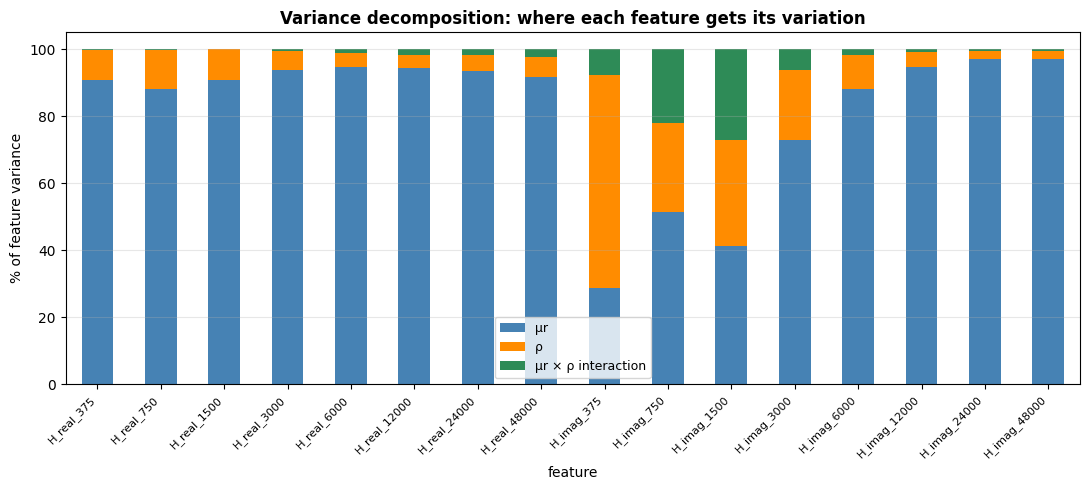

,mu_pct,rho_pct,interaction_pct
feature,,,
H_real_375,90.9,8.9,0.2
H_real_750,88.0,11.7,0.3
H_real_1500,90.7,9.2,0.1
H_real_3000,93.8,5.5,0.6
H_real_6000,94.6,4.1,1.3
H_real_12000,94.3,4.0,1.6
H_real_24000,93.4,4.7,1.9
H_real_48000,91.7,5.9,2.4
H_imag_375,28.8,63.3,7.8


In [9]:
freqs = sorted({int(c.split('_')[-1]) for c in wide_df.columns[2:]})
feature_cols = [f'{p}_{f}' for p in ('H_real', 'H_imag') for f in freqs]

rows = []
for c in feature_cols:
    tot = wide_df[c].var(ddof=0)
    v_mu = wide_df.groupby('permeability')[c].mean().var(ddof=0)
    v_rho = wide_df.groupby('resistivity')[c].mean().var(ddof=0)
    rows.append((c, (v_mu/tot)*100, (v_rho/tot)*100, ((tot-v_mu-v_rho)/tot)*100))

var_split = pd.DataFrame(rows, columns=['feature', 'mu_pct', 'rho_pct', 'interaction_pct']).set_index('feature') 

fig, ax = plt.subplots(figsize=(11, 5))
var_split.plot(kind='bar', stacked=True, ax=ax,
               color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylabel('% of feature variance')
ax.set_title('Variance decomposition: where each feature gets its variation', fontweight='bold')
ax.legend(['μr', 'ρ', 'μr × ρ interaction'], fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(fig_dir / 'variance_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

var_split.round(1)   

**Key Observations from Variance Decomposition:**
- Each feature's 225 values vary because only two things changed across the sweep: μr and ρ. The table above splits that variation into three parts: the share that tracks μr, the share that tracks ρ,  and the share that depends on both together (interaction). Because every μr x ρ combination is simulated exactly once with none missing, the split is exact. The three shares always total 100% and interaction can never come out negative.

- For the H_real channel, interaction is below < 1% till 3kHz and ≤ 2.4% above it. μr and ρ act on the real part almost independently.

- H_imag's composition changes drastically across the spectrum. At 375Hz, ρ accounts for 63.3% of its variance, more than twice μr's 28.8%. By 24kHz, that has inverted completely, μr 97.1%, ρ 2.4%. H_imag_24000 and H_imag_48000 are close to pure permeability channels.

- The μr x ρ interaction is concentrated at low-mid frequency in H_imag, 21.9% at 750Hz and 27.0% at 1500Hz, falling to ≤ 1.7% from 6kHz upward. This is the crossover region, where μr's two competing effects (stronger eddy currents -> more loss vs thinner skin depth -> less loss) balance, and which one dominates depends on ρ.

- H_real's  ρ share is small but never vanishes, 4.0-11.7% across the spectrum, lowest in the 6-24kHz band. Unlike H_imag, it carries some ρ at every frequency.

Caveat: These shares describe the sweep, not the sensor. μr was swept over 1000x and ρ only 5x, so μr's share is inflated by the design. The table shows where each feature's variation comes from in the grid. It does not show how recoverable either target is. Comparisons across frequency within a feature are unaffected, since the sweep is identical at both ends.

## 7. Principal Component Analysis
PCA is a multivariate technique which transforms high-dimensional datasets into few uncorrelated variables(Principal Components) that capture the maximum variance from data. Here, PCA is used on the features isolated from targets to visualise global structures and identify which broad group of features are driving the variance in the data. 

In [10]:
from sklearn.decomposition import PCA

def compute_pca(input_data, data_label, feature_names, figure_dir,  
                n_components=3, annotate_scores=False):

    # PCA with scree, score and loading plots
    print(f'For {data_label} data')
    pca = PCA(n_components)
    pc = pca.fit_transform(input_data)

    # percentage of variance each PC accounts for
    per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
    # One Label per PC
    labels = [f'PC{i}' for i in range(1, len(per_var)+1)]
    axis_label = {l:f'{l} = {v}%' for l, v in zip(labels, per_var)}

    # Scree Plot
    fig, ax = plt.subplots(figsize=(5,4), constrained_layout=True)
    ax.bar(labels, per_var, width=0.5)
    for l, v in zip(labels, per_var):
        ax.text(l, v, f'{v}%', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('Percentage of Exlplained Variance')
    ax.set_xlabel('Principal Component')
    ax.set_title(f'Scree Plot ({data_label} Data)')
    fig.savefig(figure_dir / f'pca_scree_{data_label.lower()}.png', dpi=150)
    plt.show()    

    # PCA Loadings
    pca_df = pd.DataFrame(pca.components_.T, index=feature_names, columns=labels)
    # PCA scores for each sample
    pca_scores = pd.DataFrame(pc, columns=labels, 
                              index=getattr(input_data, 'index', None))

    # PC1 against each remaining component
    pairs = [(labels[0], l) for l in labels[1:]]
    if not pairs: # n_components=1 nothing to plot against
        return pca_df, pca_scores, per_var

    # PCA Score Plots
    fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5), 
                             squeeze=False, constrained_layout=True)
    for ax, (x1, y1) in zip(axes[0], pairs):
        ax.scatter(pca_scores[x1], pca_scores[y1], s=35)
        ax.set_xlabel(axis_label[x1])
        ax.set_ylabel(axis_label[y1])
        ax.set_title(f'Scores: {x1} vs {y1}')
        ax.grid(True, alpha=0.3)
        if annotate_scores:
            for idx in pca_scores.index:
                plt.annotate(idx, (pca_scores[x1].loc[idx], 
                                  pca_scores[y1].loc[idx]), fontsize=6)
    fig.suptitle(f'PCa Score Plots ({data_label} Data)')            
    plt.show()  

    # PCA Loading Plot
    fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5), 
                             squeeze=False, constrained_layout=True)
    for ax, (x1, y1) in zip(axes[0], pairs):
        ax.scatter(pca_df[x1], pca_df[y1], s=35)
        ax.axhline(0, color='gray', lw=0.8)
        ax.axvline(0, color='gray', lw=0.8)
        ax.set_xlabel(axis_label[x1])
        ax.set_ylabel(axis_label[y1])
        ax.set_title(f'Scores: {x1} vs {y1}')
        ax.grid(True, alpha=0.3)
        for feat in pca_df.index:
            ax.annotate(feat, (pca_df[x1].loc[feat], 
                                  pca_df[y1].loc[feat]), fontsize=6)
    fig.suptitle(f'PCa Loading Plots ({data_label} Data)')            
    plt.show()  

    # Loading scores 
    for l in labels:
        s = pca_df[l].reindex(pca_df[l].abs().sort_values(ascending=False).index)
        print(f'\n{l} Loading Scores ({data_label} Data):\n{s.round(3).to_string()}')
    
    return pca_df, pca_scores, per_var

For Scaled data


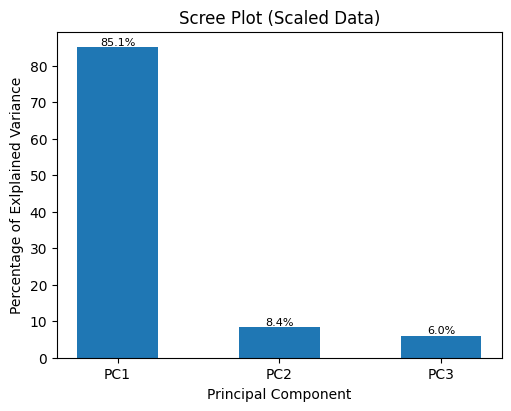

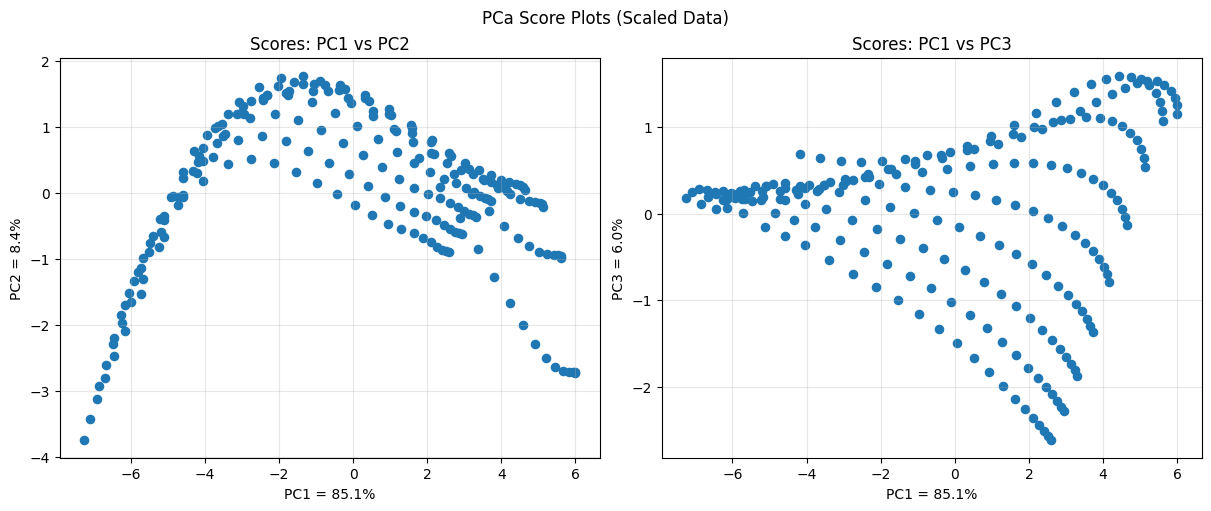

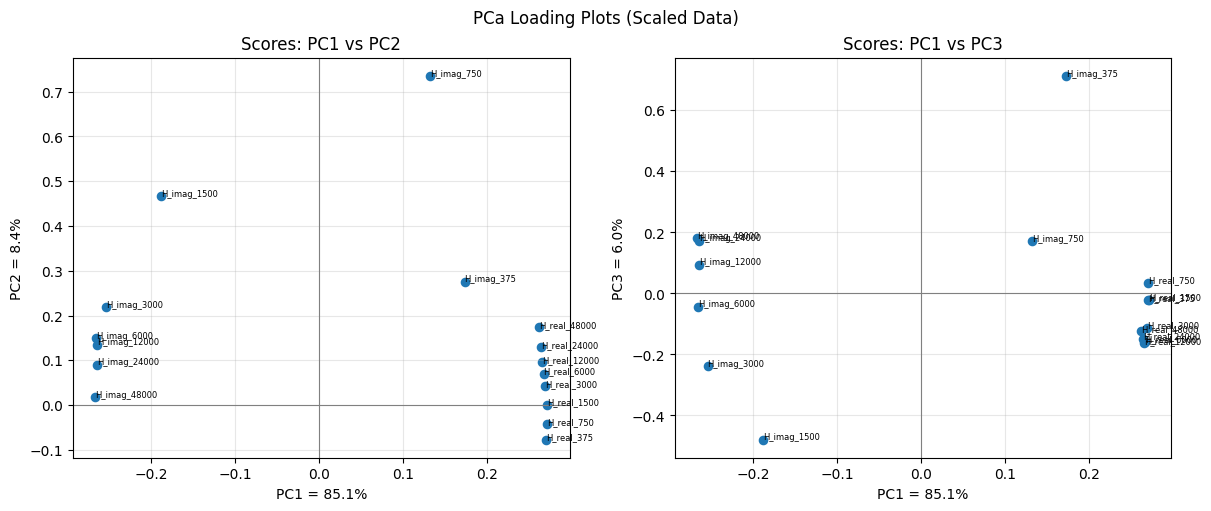


PC1 Loading Scores (Scaled Data):
H_real_1500     0.271
H_real_750      0.270
H_real_375      0.270
H_real_3000     0.269
H_real_6000     0.267
H_imag_48000   -0.266
H_real_12000    0.265
H_imag_6000    -0.265
H_imag_24000   -0.265
H_imag_12000   -0.264
H_real_24000    0.264
H_real_48000    0.261
H_imag_3000    -0.254
H_imag_1500    -0.189
H_imag_375      0.173
H_imag_750      0.132

PC2 Loading Scores (Scaled Data):
H_imag_750      0.734
H_imag_1500     0.466
H_imag_375      0.276
H_imag_3000     0.218
H_real_48000    0.174
H_imag_6000     0.150
H_imag_12000    0.135
H_real_24000    0.129
H_real_12000    0.095
H_imag_24000    0.090
H_real_375     -0.077
H_real_6000     0.070
H_real_750     -0.043
H_real_3000     0.042
H_imag_48000    0.018
H_real_1500     0.001

PC3 Loading Scores (Scaled Data):
H_imag_375      0.712
H_imag_1500    -0.479
H_imag_3000    -0.238
H_imag_48000    0.180
H_imag_24000    0.172
H_imag_750      0.172
H_real_12000   -0.164
H_real_6000    -0.158
H_real_24000   

In [11]:
# Scaling data
from sklearn.preprocessing import StandardScaler

unscaled_data = wide_df.iloc[:, 2:]
features = unscaled_data.columns.to_list()

scaler = StandardScaler()
scaled_data= scaler.fit_transform(unscaled_data)

sc_loadings, sc_scores, sc_var = compute_pca(scaled_data, 'Scaled', features, fig_dir)

In [12]:
# Score-target correlations: correlate PCA sample scores with the targets
targets = wide_df[['permeability', 'resistivity']].reset_index(drop=True)
scores_for_corr = sc_scores.reset_index(drop=True)

sc_score_target_corr = scores_for_corr.join(targets).corr(method='spearman')
print('PCA Score - Target Correlation (Spearman):')
sc_score_target_corr.loc[sc_scores.columns.to_list(), ['permeability', 'resistivity']]


PCA Score - Target Correlation (Spearman):


,permeability,resistivity
PC1,-0.930717,-0.333022
PC2,0.204112,-0.185619
PC3,0.180560,-0.853623


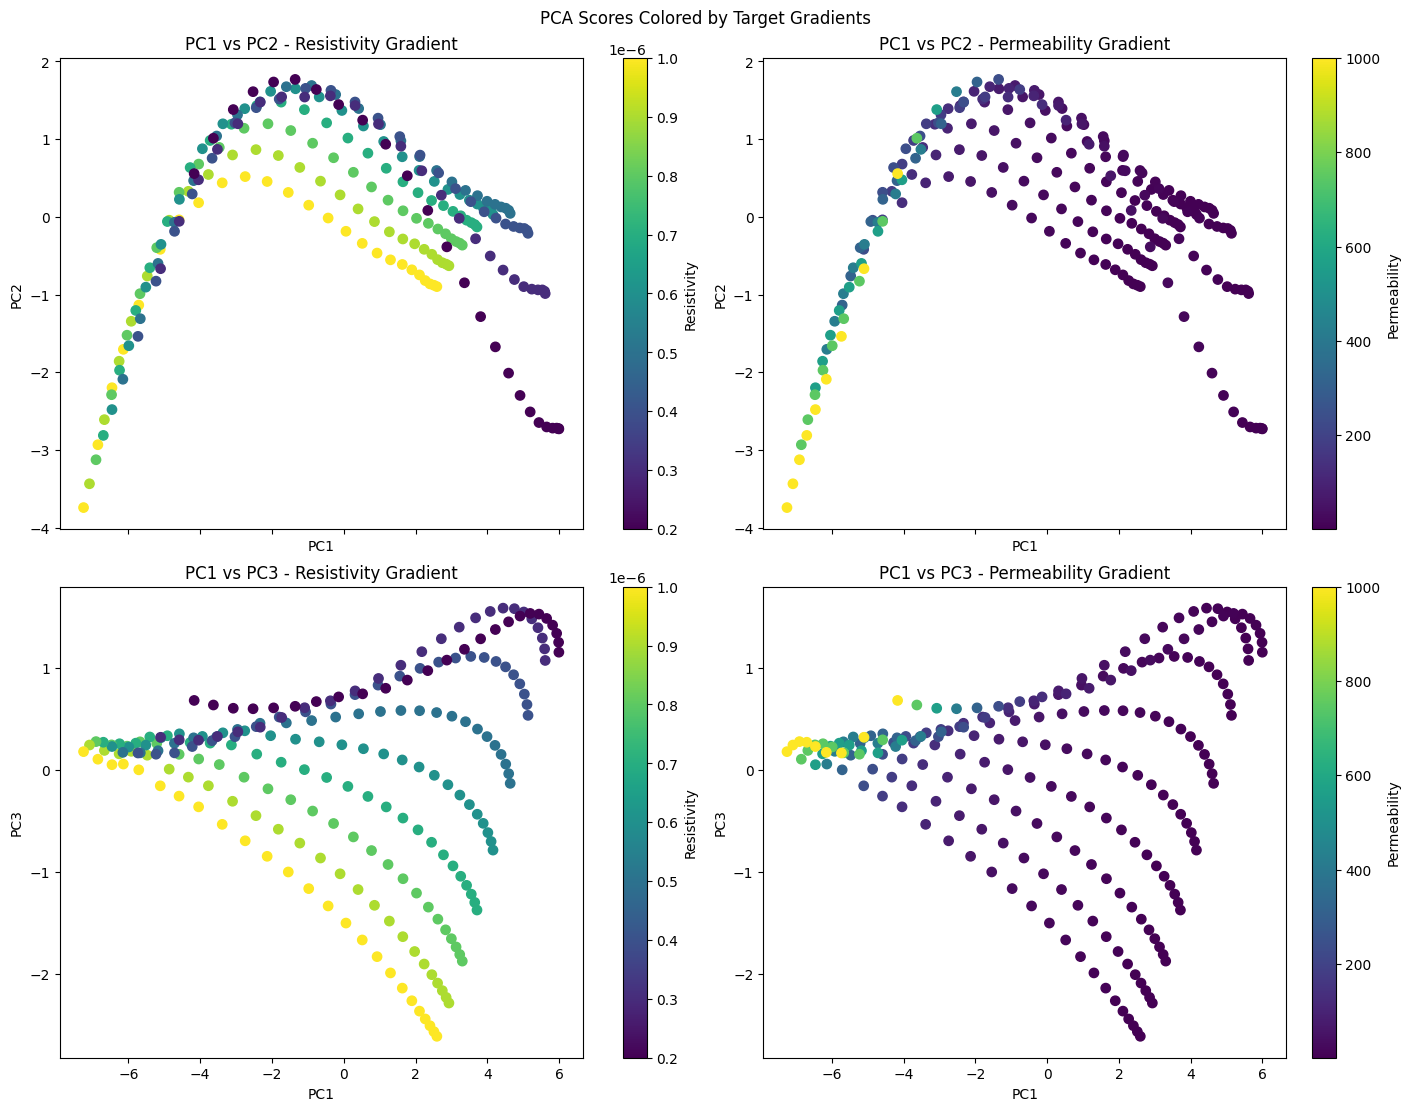

: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, constrained_layout=True)

for row, ycol in enumerate(['PC2', 'PC3']):
    for col, (tgt, lab) in enumerate([('resistivity', 'Resistivity'), 
                                      ('permeability', 'Permeability')]):
        sc = axes[row, col].scatter(sc_scores['PC1'], sc_scores[ycol],
                                    c=wide_df[tgt], cmap='viridis', s=45)
        axes[row, col].set_xlabel('PC1')
        axes[row, col].set_ylabel(ycol)
        axes[row, col].set_title(f'PC1 vs {ycol} - {lab} Gradient')
        fig.colorbar(sc, ax=axes[row, col], label=lab)

fig.suptitle('PCA Scores Colored by Target Gradients')
plt.show()

    
## Summary of Scaled PCA Results 
- PC1, PC2, PC3 combined explain 99.5% of variance in data.

- PC1 is dominated by μr but is not a pure μr axis. It correlates |0.93| with μr and |0.33| with ρ. μr dominance can also be an attribute of 1000x sweep of μr against ρ's 5x sweep, so μr would lead PC1's correlation even if the component weighted both equally.  
Its loadings put all eight H_real features positive with tightly clustered weights (0.26-0.27). H_real and H_imag load with opposite signs from 1.5kHZ upward, and with the same sign at 375 and 750Hz.
The sign flip of H_imag in PC1 is also observed in the inductance-frequency plot, where the order of permeability curves flip across 1.5kHz.
(Principal component signs are arbitrary, so only the relative pattern is meaningful.)

- PC2 is an artifact, not a physical direction. It correlates only |0.20| with μr and |0.19| with ρ

- PC3 is the resistivity direction. It correlates |0.85| with ρ against |0.18| with μr. Here the sweep bias runs against the finding. ρ was swept only 5x so reaching |0.85| on the narrowly swept target is stronger evidence than PC1's |0.93| on the widely swept one. Its loadings show H_imag with highest correlation at 375Hz(0.71), matching section 5, where H_imag_375 carries the largest ρ share of any feature (63.3%).

- PC2 is not an independent direction of material variation. It correlates only |0.20| with μr and |0.19| with ρ, and the score plot is a horseshoe: the 225 points form five nested arcs (one per ρ), with μr running along each arc. Following that arc, PC2 rises to a crest and falls again. So PC2 is largely determined by position along the PC1 gradient, not by a seperate material property. This is the horeshoe effect: The arch appears when samples lie along a single dominant ordered gradient having a non-linear relationship with the features. This causes a linear PCA to bend the gradient into an arch because it can't represent a curved structure with linear components.


## Summary of EDA Results 
- Both targets act on H_real and H_imag at every frequency. There is no seperate effect.

- ρ's frequency structure differs sharply between the two components. H_imag carries ρ the most, out of any features, at 375Hz (63.3%) and 2.4% at 24kHz. H_real's variance composition stays within 4-12% throughout. 

- The μr × ρ interaction is never above 2.4% in H_real but 21.9% at 750Hz and 27.0% at 1.5kHz in H_imag. It concides with the band where both H_imag panels reverse their curve ordering.

- **Caveats:** Variance shares are not comparable across targets, μr was swept over 1000x and ρ only 5x, so the design contributes as much as the sensor. Comparisons across frequency within a feature are unaffected, And this describes the forward response only. How recoverable each target is from H is a modelling question.